In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pickle

In [11]:
df_high = pd.read_csv('/content/sample_data/high_popularity_spotify_data.csv')
df_low = pd.read_csv('/content/sample_data/low_popularity_spotify_data.csv')

In [12]:
cols = ['energy', 'valence', 'tempo', 'danceability', 'acousticness', 'instrumentalness', 'track_name', 'track_artist']
df = pd.concat([df_high[cols], df_low[cols]], ignore_index=True).dropna()
print(f"Total songs after combining and cleaning: {len(df)}")

Total songs after combining and cleaning: 4830


In [13]:
def label_mood(row):
    v = row['valence']
    e = row['energy']
    if v > 0.5 and e > 0.5:    return 'Happy'      # High valence, high energy
    if v <= 0.5 and e > 0.5:   return 'Energetic'  # Low valence, high energy
    if v <= 0.5 and e <= 0.5:  return 'Sad'        # Low valence, low energy
    return 'Neutral'                                # High valence, low energy

df['mood'] = df.apply(label_mood, axis=1)

print("\nMood distribution:")
print(df['mood'].value_counts())


Mood distribution:
mood
Happy        1974
Energetic    1352
Sad          1176
Neutral       328
Name: count, dtype: int64


In [14]:
features_full = ['energy', 'valence', 'tempo', 'danceability',
                 'acousticness', 'instrumentalness']
features_indirect = ['tempo', 'danceability', 'acousticness', 'instrumentalness']

y = df['mood']

results = {}

for name, feature_list in [('Full features (rule-equivalent)', features_full),
                            ('Indirect features only', features_indirect)]:
    X = df[feature_list]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'accuracy': acc,
        'y_test': y_test,
        'y_pred': y_pred,
        'features': feature_list,
    }

    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"Features used: {feature_list}")
    print(f"Test accuracy: {acc:.4f}")
    print(f"\nClassification report:")
    print(classification_report(y_test, y_pred))


Full features (rule-equivalent)
Features used: ['energy', 'valence', 'tempo', 'danceability', 'acousticness', 'instrumentalness']
Test accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

   Energetic       1.00      1.00      1.00       270
       Happy       1.00      1.00      1.00       395
     Neutral       1.00      1.00      1.00        66
         Sad       1.00      1.00      1.00       235

    accuracy                           1.00       966
   macro avg       1.00      1.00      1.00       966
weighted avg       1.00      1.00      1.00       966


Indirect features only
Features used: ['tempo', 'danceability', 'acousticness', 'instrumentalness']
Test accuracy: 0.6439

Classification report:
              precision    recall  f1-score   support

   Energetic       0.57      0.51      0.54       270
       Happy       0.63      0.76      0.69       395
     Neutral       0.30      0.12      0.17        66
         Sad       0.79 

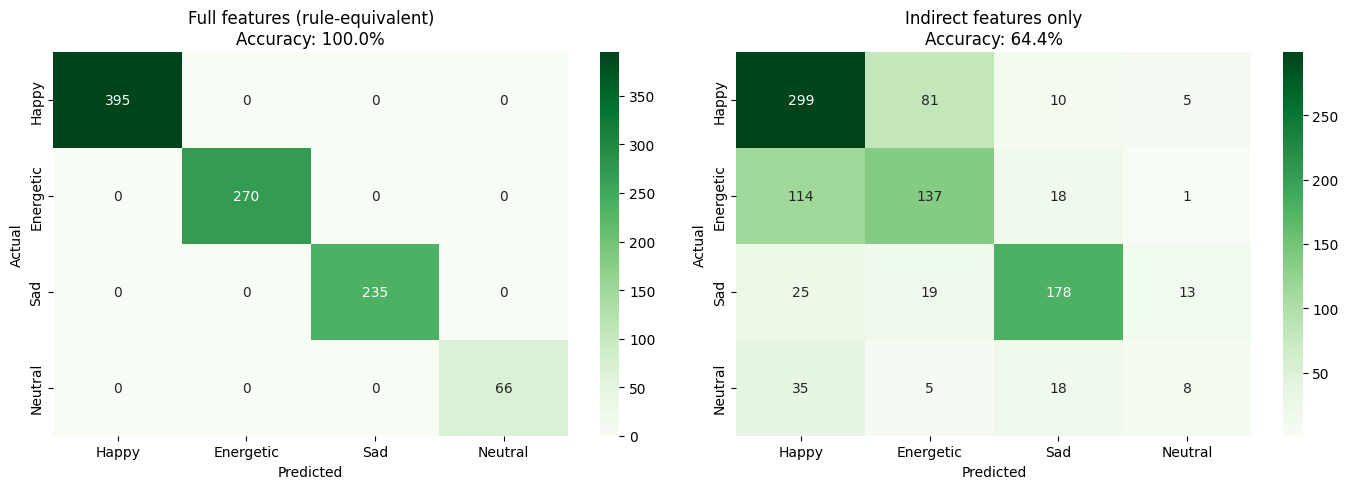

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Happy', 'Energetic', 'Sad', 'Neutral']

for ax, (name, data) in zip(axes, results.items()):
    cm = confusion_matrix(data['y_test'], data['y_pred'], labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=labels, yticklabels=labels, ax=ax, cbar=True)
    ax.set_title(f"{name}\nAccuracy: {data['accuracy']:.1%}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('music_classifier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


Feature importance — indirect features only:
         feature  importance
    acousticness    0.338775
    danceability    0.249306
           tempo    0.211719
instrumentalness    0.200200


/tmp/ipykernel_15610/913426363.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='importance', y='feature', palette='Greens_r')


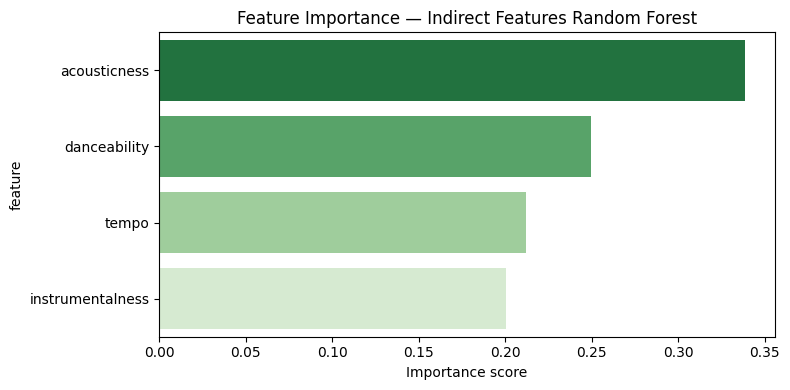

In [16]:
X_indirect = df[features_indirect]
X_train, X_test, y_train, y_test = train_test_split(
    X_indirect, y, test_size=0.2, random_state=42, stratify=y
)
rf_indirect = RandomForestClassifier(n_estimators=100, random_state=42)
rf_indirect.fit(X_train, y_train)

importances = pd.DataFrame({
    'feature': features_indirect,
    'importance': rf_indirect.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature importance — indirect features only:")
print(importances.to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(data=importances, x='importance', y='feature', palette='Greens_r')
plt.title('Feature Importance — Indirect Features Random Forest')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('feature_importance_indirect.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
X_production = df[features_full]
y_production = df['mood']

production_model = RandomForestClassifier(n_estimators=100, random_state=42)
production_model.fit(X_production, y_production)

with open('music_mood_model.pkl', 'wb') as f:
    pickle.dump(production_model, f)

print(f"\nProduction model trained on full dataset ({len(X_production)} songs)")
print(f"Saved to music_mood_model.pkl")


Production model trained on full dataset (4830 songs)
Saved to music_mood_model.pkl
